In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, dbscan
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv(r"C:\Users\pc\OneDrive\Music\Desktop\ML_Projects\Dataset\WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
# Drop ID and Target (IMPORTANT)

df = df.drop(["Id", "quality"], axis=1)

In [6]:
# Scaling Data

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [10]:
# Elbow Method

interia = []

k_range = range(1, 11)

for k in k_range:
    k_means = KMeans(n_clusters=k, random_state=42)
    k_means.fit(x_scaled)
    interia.append(k_means.inertia_)

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlabed'

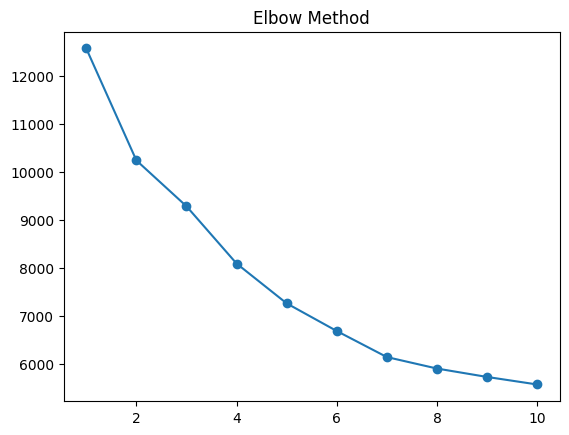

In [16]:
# Plot Elbow

plt.figure()
plt.plot(k_range, interia, marker='o')
plt.title("Elbow Method")
plt.xlabed("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [18]:
# Apply Kmeans 

k_means = KMeans(n_clusters=3, random_state=42)
Clusters = k_means.fit_predict(x_scaled)
df["cluster"] = Clusters

In [20]:
# PCA For Visualization

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

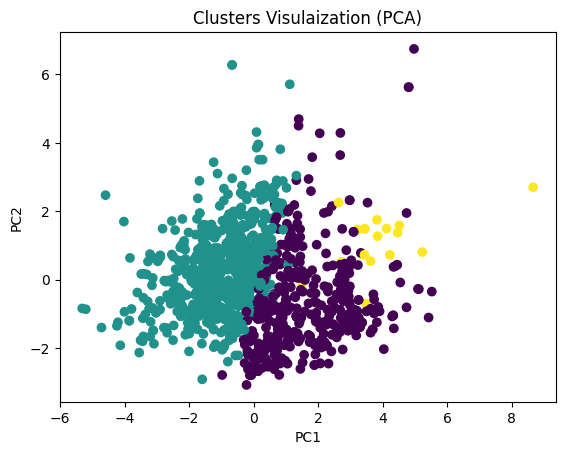

In [21]:
# Plot clusters
plt.figure()
plt.scatter(x_pca[:, 0], x_pca[:, 1], c = Clusters)
plt.title("Clusters Visulaization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()